# GMM Model Training for Attention Profiles
This version adds proper preprocessing for CPT, Stroop, and Flanker metrics
before training a Gaussian Mixture Model.

# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# LOAD DATASET

In [2]:
df_raw = pd.read_csv("attention_dataset.csv")

print("\n Dataset loaded successfully.")
print(f" Raw dataset shape: {df_raw.shape}")
print(f" Columns: {list(df_raw.columns)}")


 Dataset loaded successfully.
 Raw dataset shape: (500, 11)
 Columns: ['timestamp', 'session_id', 'CPT_RT_mean', 'CPT_RT_std', 'CPT_CV', 'CPT_omission', 'CPT_commission', 'CPT_dprime', 'CPT_sustained_slope', 'Stroop_interference', 'Flanker_effect']


# SELECT FEATURES FOR GMM

In [3]:
print(" Data Preprocessing")
print(" ")

feature_columns = [
    "CPT_RT_mean",
    "CPT_RT_std",
    "CPT_CV",
    "CPT_omission",
    "CPT_commission",
    "CPT_dprime",
    "CPT_sustained_slope",
    "Stroop_interference",
    "Flanker_effect"
]

missing_features = [col for col in feature_columns if col not in df_raw.columns]
if missing_features:
    raise ValueError(f" Missing required feature columns: {missing_features}")

# Keep only model features
df = df_raw[feature_columns].copy()

print(f" Selected GMM feature columns: {feature_columns}")
print(f" Feature-only shape: {df.shape}")

 Data Preprocessing
 
 Selected GMM feature columns: ['CPT_RT_mean', 'CPT_RT_std', 'CPT_CV', 'CPT_omission', 'CPT_commission', 'CPT_dprime', 'CPT_sustained_slope', 'Stroop_interference', 'Flanker_effect']
 Feature-only shape: (500, 9)


# REMOVE DUPLICATES

In [4]:
before_dupes = len(df)
df = df.drop_duplicates()
after_dupes = len(df)
print(f" Removed {before_dupes - after_dupes} duplicate rows")

 Removed 178 duplicate rows


# HANDLE MISSING VALUES

In [5]:
print("\n Missing values before imputation:")
print(df.isnull().sum())

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(df)

df_imputed = pd.DataFrame(X_imputed, columns=feature_columns)

print("\n Missing values handled using median imputation")
print(" Missing values after imputation:")
print(df_imputed.isnull().sum())


 Missing values before imputation:
CPT_RT_mean            0
CPT_RT_std             0
CPT_CV                 0
CPT_omission           0
CPT_commission         0
CPT_dprime             0
CPT_sustained_slope    0
Stroop_interference    0
Flanker_effect         0
dtype: int64

 Missing values handled using median imputation
 Missing values after imputation:
CPT_RT_mean            0
CPT_RT_std             0
CPT_CV                 0
CPT_omission           0
CPT_commission         0
CPT_dprime             0
CPT_sustained_slope    0
Stroop_interference    0
Flanker_effect         0
dtype: int64


# OUTLIER TREATMENT
 Clip extreme values to reduce GMM sensitivity to very abnormal observations

In [6]:
print("\n Applying outlier clipping (1st to 99th percentile)...")

df_clean = df_imputed.copy()

for col in feature_columns:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(" Outliers clipped successfully")


 Applying outlier clipping (1st to 99th percentile)...
 Outliers clipped successfully


# FEATURE SCALING

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print(" Features scaled successfully")
print(f"   Scaled data shape: {X_scaled.shape}")

 Features scaled successfully
   Scaled data shape: (322, 9)


# FIND OPTIMAL CLUSTER NUMBER (BIC)

   Clusters: 1 - BIC: 5597.54  AIC: 5393.71
   Clusters: 2 - BIC: 5178.83  AIC: 4767.40
   Clusters: 3 - BIC: 5086.99  AIC: 4467.97
   Clusters: 4 - BIC: 5328.81  AIC: 4502.18
   Clusters: 5 - BIC: 5569.83  AIC: 4535.60
   Clusters: 6 - BIC: 5792.59  AIC: 4550.76
   Clusters: 7 - BIC: 5783.48  AIC: 4334.05
   Clusters: 8 - BIC: 6233.72  AIC: 4576.69


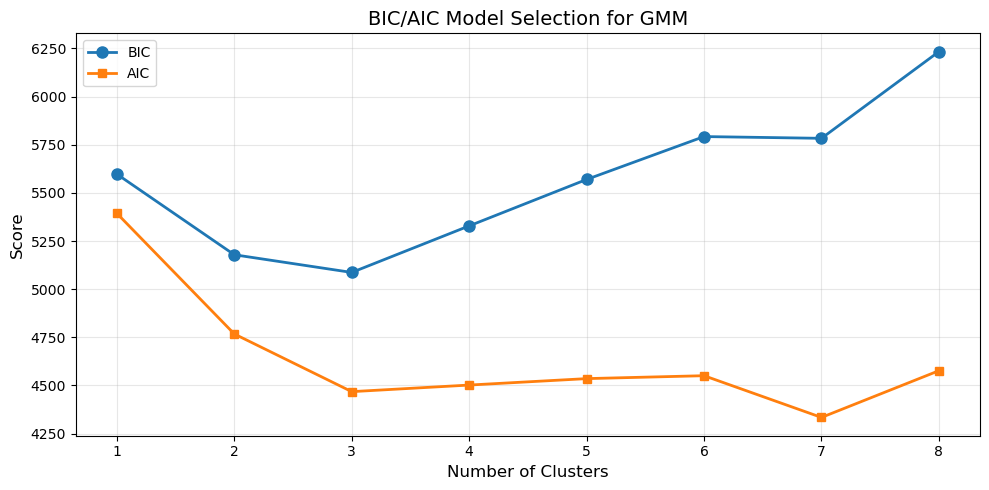

 BIC/AIC curve saved as 'bic_aic_curve.png'

 Optimal number of clusters according to BIC: 3


In [8]:
bic_scores = []
aic_scores = []
cluster_range = range(1, 9)

for n in cluster_range:
    gmm_temp = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    gmm_temp.fit(X_scaled)
    bic_scores.append(gmm_temp.bic(X_scaled))
    aic_scores.append(gmm_temp.aic(X_scaled))
    print(f"   Clusters: {n} - BIC: {bic_scores[-1]:.2f}  AIC: {aic_scores[-1]:.2f}")

# Plot BIC + AIC curve
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, bic_scores, marker='o', linewidth=2, markersize=8, label="BIC")
plt.plot(cluster_range, aic_scores, marker='s', linewidth=2, markersize=6, label="AIC")
plt.xlabel("Number of Clusters", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("BIC/AIC Model Selection for GMM", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bic_aic_curve.png', dpi=150)
plt.show()
print(" BIC/AIC curve saved as 'bic_aic_curve.png'")

optimal_clusters = cluster_range[np.argmin(bic_scores)]
print(f"\n Optimal number of clusters according to BIC: {optimal_clusters}")

# TRAIN FINAL GMM MODEL

In [9]:
gmm_model = GaussianMixture(
    n_components=optimal_clusters,
    covariance_type='full',
    random_state=42,
    n_init=10
)

gmm_model.fit(X_scaled)
print(" GMM model trained successfully")
print(f"   Number of clusters: {gmm_model.n_components}")
print(f"   Converged: {gmm_model.converged_}")

# Predict cluster labels
labels = gmm_model.predict(X_scaled)
probabilities = gmm_model.predict_proba(X_scaled)

# Save processed dataframe with clusters
df_processed = df_clean.copy()
df_processed["Cluster"] = labels

for i in range(optimal_clusters):
    df_processed[f"Cluster_{i}_prob"] = probabilities[:, i]

print(f"\n Cluster distribution:")
for cluster_id in range(optimal_clusters):
    count = (labels == cluster_id).sum()
    percentage = (count / len(labels)) * 100
    print(f"   Cluster {cluster_id}: {count} participants ({percentage:.1f}%)")

 GMM model trained successfully
   Number of clusters: 3
   Converged: True

 Cluster distribution:
   Cluster 0: 105 participants (32.6%)
   Cluster 1: 100 participants (31.1%)
   Cluster 2: 117 participants (36.3%)


# EVALUATE CLUSTERING QUALITY

In [10]:
if optimal_clusters > 1:
    sil_score = silhouette_score(X_scaled, labels)
    print(f" Silhouette Score: {sil_score:.4f}")
else:
    sil_score = None
    print(" Silhouette score not applicable for 1 cluster")

 Silhouette Score: 0.4583


# VISUALIZE CLUSTERS WITH PCA

PCA explained variance: PC1: 70.13%, PC2: 9.84%


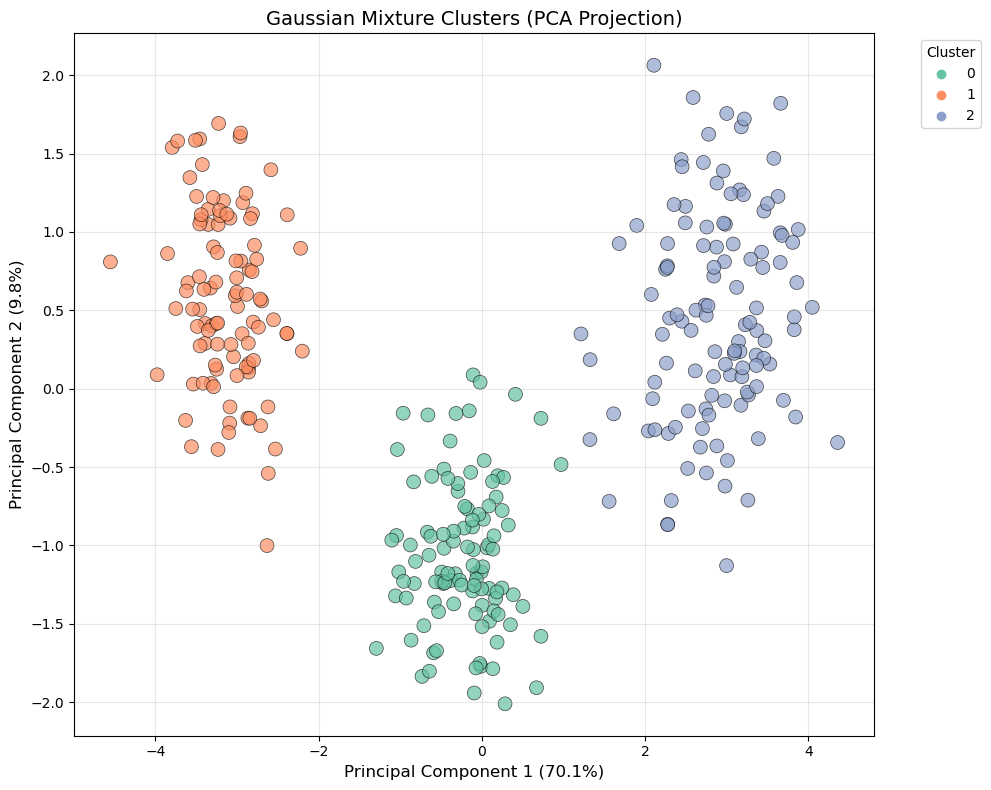

 Cluster visualization saved as 'cluster_visualization.png'


In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: PC1: {pca.explained_variance_ratio_[0]:.2%}, PC2: {pca.explained_variance_ratio_[1]:.2%}")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette="Set2",
    s=100,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.title("Gaussian Mixture Clusters (PCA Projection)", fontsize=14)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cluster visualization saved as 'cluster_visualization.png'")

# INTERPRET CLUSTERS

In [12]:
cluster_profiles = df_processed.groupby("Cluster")[feature_columns].mean()
print("\nCluster Feature Means:\n")
print(cluster_profiles.round(2))

cluster_profiles.to_csv('cluster_profiles.csv')
df_processed.to_csv('preprocessed_clustered_dataset.csv', index=False)

print("\n Cluster profiles saved as 'cluster_profiles.csv'")
print(" Processed dataset with labels saved as 'preprocessed_clustered_dataset.csv'")


Cluster Feature Means:

         CPT_RT_mean  CPT_RT_std  CPT_CV  CPT_omission  CPT_commission  \
Cluster                                                                  
0             314.98      142.27    0.40         17.89            4.05   
1             427.83      120.93    0.28         10.24            2.99   
2             363.33      195.22    0.54         24.62            5.85   

         CPT_dprime  CPT_sustained_slope  Stroop_interference  Flanker_effect  
Cluster                                                                        
0              0.25                 0.41                74.48           39.82  
1              1.17                 0.60                59.25            9.82  
2             -0.44                 0.19               109.94           78.95  

 Cluster profiles saved as 'cluster_profiles.csv'
 Processed dataset with labels saved as 'preprocessed_clustered_dataset.csv'


# SAVE TRAINED MODEL

In [13]:
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(gmm_model, "gmm_model.pkl")
joblib.dump(gmm_model, "models/gmm_model.pkl")

joblib.dump(scaler, "scaler.pkl")
joblib.dump(scaler, "models/scaler.pkl")

joblib.dump(imputer, "imputer.pkl")
joblib.dump(imputer, "models/imputer.pkl")

metadata = {
    'optimal_clusters': int(optimal_clusters),
    'silhouette_score': None if sil_score is None else float(sil_score),
    'feature_names': feature_columns,
    'cluster_sizes': {int(k): int(v) for k, v in df_processed['Cluster'].value_counts().to_dict().items()},
    'cluster_profiles': cluster_profiles.to_dict(),
    'pca_components': pca.components_.tolist(),
    'pca_explained_variance': pca.explained_variance_ratio_.tolist(),
    'bic_scores': {int(k): float(v) for k, v in zip(cluster_range, bic_scores)},
    'aic_scores': {int(k): float(v) for k, v in zip(cluster_range, aic_scores)}
}

joblib.dump(metadata, "model_metadata.pkl")
joblib.dump(metadata, "models/model_metadata.pkl")

print(" GMM model, scaler, imputer, and metadata saved")

 GMM model, scaler, imputer, and metadata saved


# VERIFY MODELS Load Correctly

In [14]:
try:
    test_gmm = joblib.load("gmm_model.pkl")
    test_scaler = joblib.load("scaler.pkl")
    test_imputer = joblib.load("imputer.pkl")

    print(" Models loaded successfully")
    print(f"   GMM clusters: {test_gmm.n_components}")

    sample_data = df_raw[feature_columns].iloc[[0]]
    sample_imputed = test_imputer.transform(sample_data)
    sample_scaled = test_scaler.transform(sample_imputed)
    sample_pred = test_gmm.predict(sample_scaled)[0]

    print(f"   Sample prediction: Cluster {sample_pred}")

except Exception as e:
    print(f" Error loading models: {e}")

 Models loaded successfully
   GMM clusters: 3
   Sample prediction: Cluster 0


c:\Users\senes\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# SUMMARY

In [17]:
print(" TRAINING COMPLETE")
print("\n Files saved:")
print("    gmm_model.pkl")
print("    scaler.pkl")
print("    imputer.pkl")
print("    model_metadata.pkl")
print("    cluster_profiles.csv")
print("    preprocessed_clustered_dataset.csv")
print("    cluster_visualization.png")
print("    bic_aic_curve.png")

print("\n Model Summary:")
print(f"   Optimal clusters: {optimal_clusters}")
if sil_score is not None:
    print(f"   Silhouette score: {sil_score:.4f}")
print(f"   Features used: {len(feature_columns)}")

 TRAINING COMPLETE

 Files saved:
    gmm_model.pkl
    scaler.pkl
    imputer.pkl
    model_metadata.pkl
    cluster_profiles.csv
    preprocessed_clustered_dataset.csv
    cluster_visualization.png
    bic_aic_curve.png

 Model Summary:
   Optimal clusters: 3
   Silhouette score: 0.4583
   Features used: 9
